In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv', encoding='utf-8-sig')

print(f'shape: {df.shape}')
print(f'폐업률 범위: {df["폐업률"].min():.2f}% ~ {df["폐업률"].max():.2f}%')
print(df.head(3))

shape: (1050, 29)
폐업률 범위: 1.98% ~ 23.76%
    구명    연도     업종       평균_당월매출     연령대_20_매출     연령대_30_매출     연령대_40_매출  \
0  강남구  2019  분식전문점  6.533841e+08  1.279386e+08  1.448395e+08  1.427872e+08   
1  강남구  2019  양식음식점  1.366631e+09  2.688714e+08  3.211270e+08  2.250849e+08   
2  강남구  2019  일식음식점  9.675838e+08  1.774149e+08  2.076301e+08  1.397524e+08   

      연령대_50_매출  주말_매출_비율    폐업률  ...          평균_하차    총_직장인구  직장인구_20대  \
0  8.195965e+07    0.2211   7.82  ...  630089.903646  937043.0  186311.0   
1  1.425676e+08    0.2955   9.90  ...  630089.903646  937043.0  186311.0   
2  8.413404e+07    0.1966  10.23  ...  630089.903646  937043.0  186311.0   

   직장인구_30대  직장인구_40대  직장인구_50대     임대료  임대료_증감률  경쟁강도  임대료_매출_비율  
0  286727.0  238932.0  155251.0  130580      0.0   919   0.000200  
1  286727.0  238932.0  155251.0  130580      0.0  2267   0.000096  
2  286727.0  238932.0  155251.0  130580      0.0   842   0.000135  

[3 rows x 29 columns]


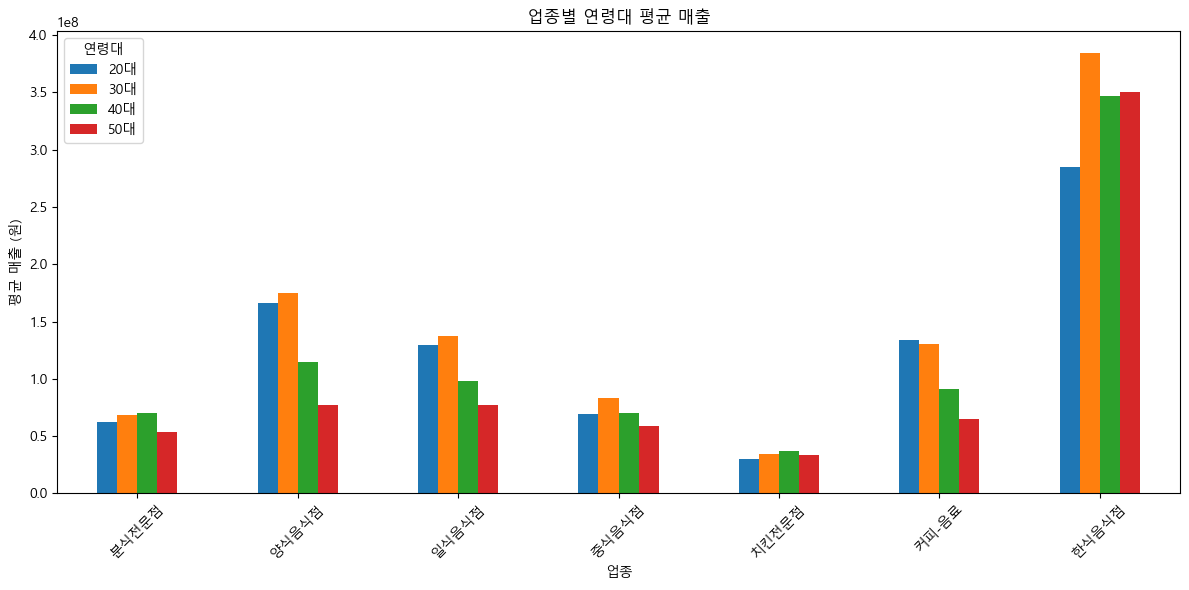

               20대          30대          40대          50대
업종                                                       
분식전문점   62664445.0   68681636.0   70200646.0   53841094.0
양식음식점  165806887.0  174910036.0  114714312.0   76819424.0
일식음식점  129257689.0  137594304.0   97879242.0   77079845.0
중식음식점   69418002.0   83282749.0   70053901.0   59177335.0
치킨전문점   30366011.0   34326533.0   37043782.0   33282103.0
커피-음료  133661675.0  130183849.0   91435366.0   64977904.0
한식음식점  284573277.0  384127443.0  347191957.0  350749193.0


In [3]:
age_cols = ['연령대_20_매출', '연령대_30_매출', '연령대_40_매출', '연령대_50_매출']

df_age = df.groupby('업종')[age_cols].mean()
df_age.columns = ['20대', '30대', '40대', '50대']

df_age.plot(kind='bar', figsize=(12, 6))
plt.title('업종별 연령대 평균 매출')
plt.xlabel('업종')
plt.ylabel('평균 매출 (원)')
plt.xticks(rotation=45)
plt.legend(title='연령대')
plt.tight_layout()
plt.show()

print(df_age.round(0))

#### 한식의 압도적인 이유
#### 가장 보편적인 외식업종
#### 매장수 자체가 가장 많아서 매출 합계 도 높음
#### 모든 연령대에서 고르게 소비






#### 양식/일식 → 20대, 30대 비중 높음 젊은 층이 선호

#### 커피-음료  → 20대 매출이 30대보다 높음 카페는 20대가 주도

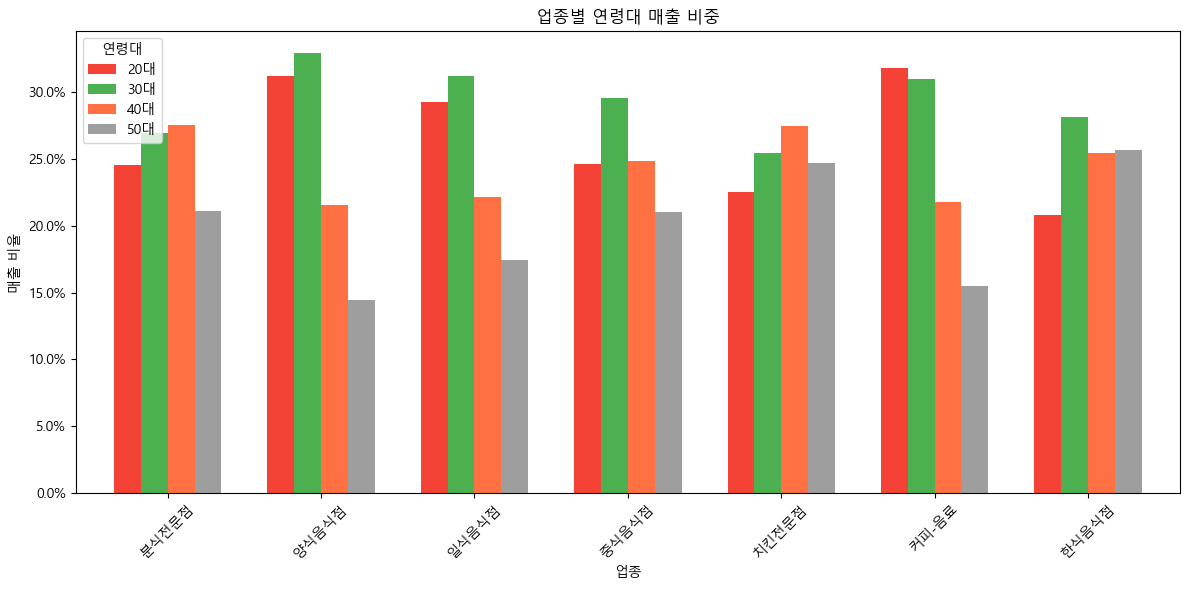

In [4]:
# 업종별 연령대 매출 비중 비교

age_sales_cols = ['연령대_20_매출', '연령대_30_매출', '연령대_40_매출', '연령대_50_매출']

df_age_sales = df.groupby('업종')[age_sales_cols].mean()

# 각 업종별로 연령대 합계 대비 비율로 변환
df_age_sales_ratio = df_age_sales.div(df_age_sales.sum(axis=1), axis=0).round(4)
df_age_sales_ratio.columns = ['20대', '30대', '40대', '50대']

df_age_sales_ratio.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#F44336', '#4CAF50', '#FF7043', '#9E9E9E'], 
    width=0.7
)
plt.title('업종별 연령대 매출 비중')
plt.xlabel('업종')
plt.ylabel('매출 비율')
plt.xticks(rotation=45)
plt.legend(title='연령대', loc='upper left')

import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

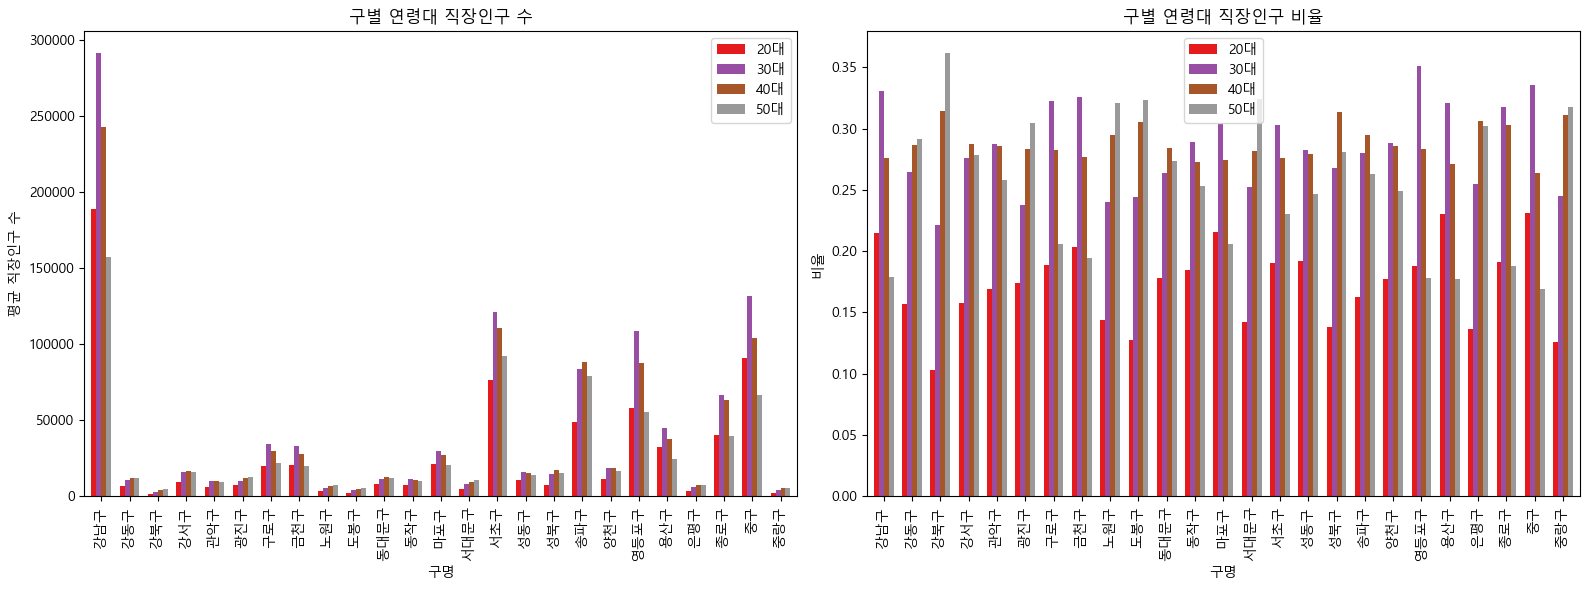

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 구별 연령대 직장인구 수 (절대값)
age_work_cols = ['직장인구_20대', '직장인구_30대', '직장인구_40대', '직장인구_50대']
df_work = df.groupby('구명')[age_work_cols].mean()
df_work.columns = ['20대', '30대', '40대', '50대']
df_work.plot(kind='bar', ax=axes[0], colormap='Set1', width=0.7)
axes[0].set_title('구별 연령대 직장인구 수')
axes[0].set_xlabel('구명')
axes[0].set_ylabel('평균 직장인구 수')
axes[0].tick_params(axis='x', rotation=90)

# 오른쪽: 구별 연령대 직장인구 비율
df_work_ratio = df_work.div(df_work.sum(axis=1), axis=0).round(4)
df_work_ratio.plot(kind='bar', ax=axes[1], colormap='Set1', width=0.7)
axes[1].set_title('구별 연령대 직장인구 비율')
axes[1].set_xlabel('구명')
axes[1].set_ylabel('비율')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

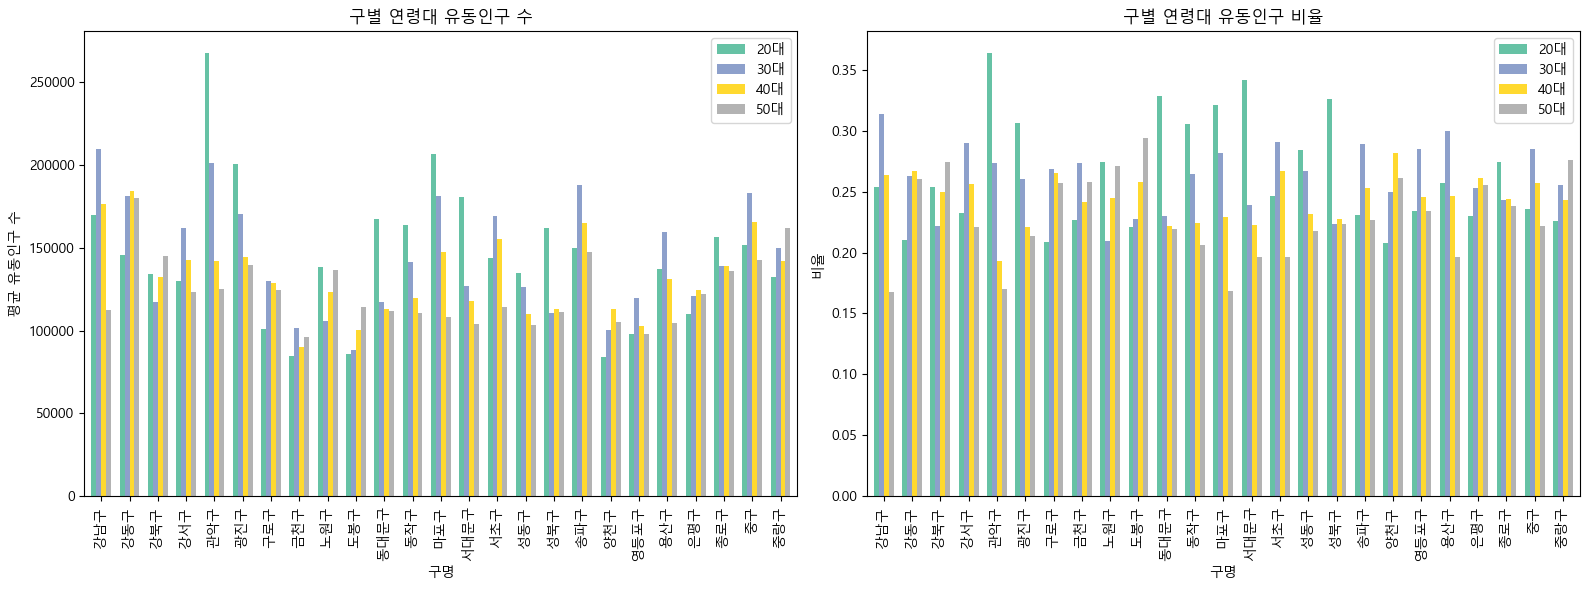

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 구별 연령대 유동인구 수 (절대값)
age_flow_cols = ['유동인구_20대', '유동인구_30대', '유동인구_40대', '유동인구_50대']
df_flow = df.groupby('구명')[age_flow_cols].mean()
df_flow.columns = ['20대', '30대', '40대', '50대']
df_flow.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.7)
axes[0].set_title('구별 연령대 유동인구 수')
axes[0].set_xlabel('구명')
axes[0].set_ylabel('평균 유동인구 수')
axes[0].tick_params(axis='x', rotation=90)

# 오른쪽: 구별 연령대 유동인구 비율
df_flow_ratio = df_flow.div(df_flow.sum(axis=1), axis=0).round(4)
df_flow_ratio.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_title('구별 연령대 유동인구 비율')
axes[1].set_xlabel('구명')
axes[1].set_ylabel('비율')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

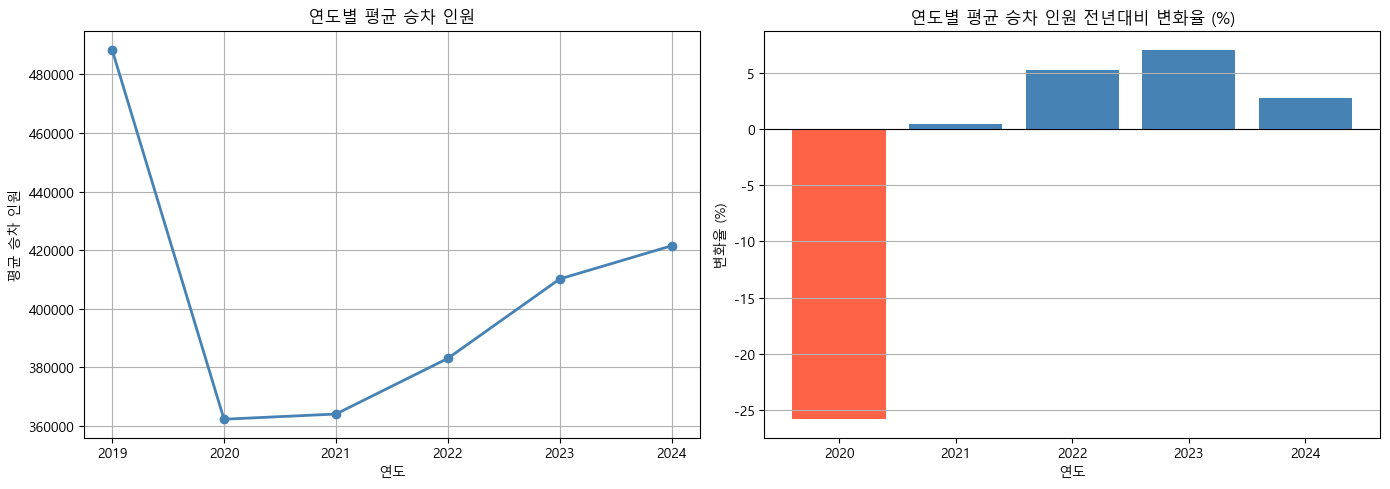

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_subway = df.groupby('연도')[['평균_승차', '평균_하차']].mean().reset_index()

# 왼쪽: 연도별 평균 승차 인원
axes[0].plot(df_subway['연도'], df_subway['평균_승차'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('연도별 평균 승차 인원')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('평균 승차 인원')
axes[0].grid(True)

# 오른쪽: 전년대비 승차 변화율
df_subway['승차_변화율'] = df_subway['평균_승차'].pct_change().round(4) * 100
axes[1].bar(df_subway['연도'][1:], df_subway['승차_변화율'][1:],
            color=['tomato' if x < 0 else 'steelblue' for x in df_subway['승차_변화율'][1:]])
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('연도별 평균 승차 인원 전년대비 변화율 (%)')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('변화율 (%)')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

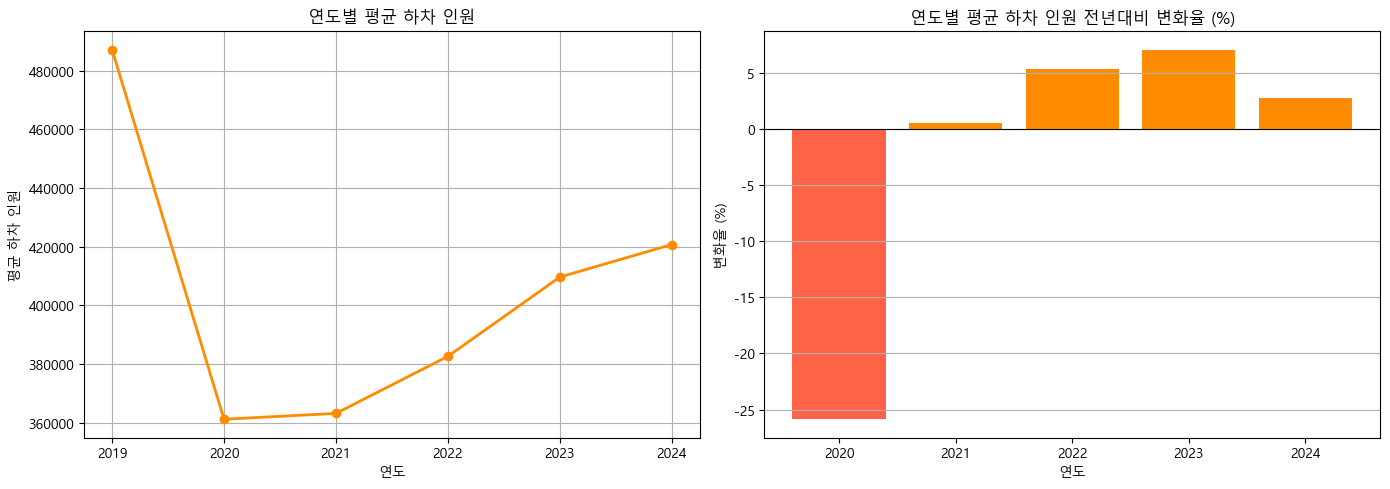

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 연도별 평균 하차 인원
axes[0].plot(df_subway['연도'], df_subway['평균_하차'], marker='o', color='darkorange', linewidth=2)
axes[0].set_title('연도별 평균 하차 인원')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('평균 하차 인원')
axes[0].grid(True)

# 오른쪽: 전년대비 하차 변화율
df_subway['하차_변화율'] = df_subway['평균_하차'].pct_change().round(4) * 100
axes[1].bar(df_subway['연도'][1:], df_subway['하차_변화율'][1:],
            color=['tomato' if x < 0 else 'darkorange' for x in df_subway['하차_변화율'][1:]])
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('연도별 평균 하차 인원 전년대비 변화율 (%)')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('변화율 (%)')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [9]:
# 구별 주요 연령대 + 폐업률 낮은 업종
df_q6 = df.groupby(['구명', '업종']).agg(
    평균_폐업률=('폐업률', 'mean'),
    연령_20대=('유동인구_20대', 'mean'),
    연령_30대=('유동인구_30대', 'mean'),
    연령_40대=('유동인구_40대', 'mean'),
    연령_50대=('유동인구_50대', 'mean'),
).reset_index()

# 주요 연령대 찾기
age_cols = ['연령_20대', '연령_30대', '연령_40대', '연령_50대']
df_q6['주요연령대'] = df_q6[age_cols].idxmax(axis=1).str.replace('연령_', '')

print(df_q6.groupby(['주요연령대', '업종'])['평균_폐업률'].mean().unstack().round(2))

업종     분식전문점  양식음식점  일식음식점  중식음식점  치킨전문점  커피-음료  한식음식점
주요연령대                                                 
20대    10.13  11.30   9.59   8.51   9.69  12.37   8.64
30대     9.18  10.62   9.48   8.57   9.76  12.09   8.64
40대    11.13  11.34  11.26   9.32   9.86  13.58   9.92
50대     9.75  10.60   9.58   8.14   8.77  12.48   9.56


#### 커피-음료(카폐)는 연령대 불문 압도적인 폐업률을 보여준다


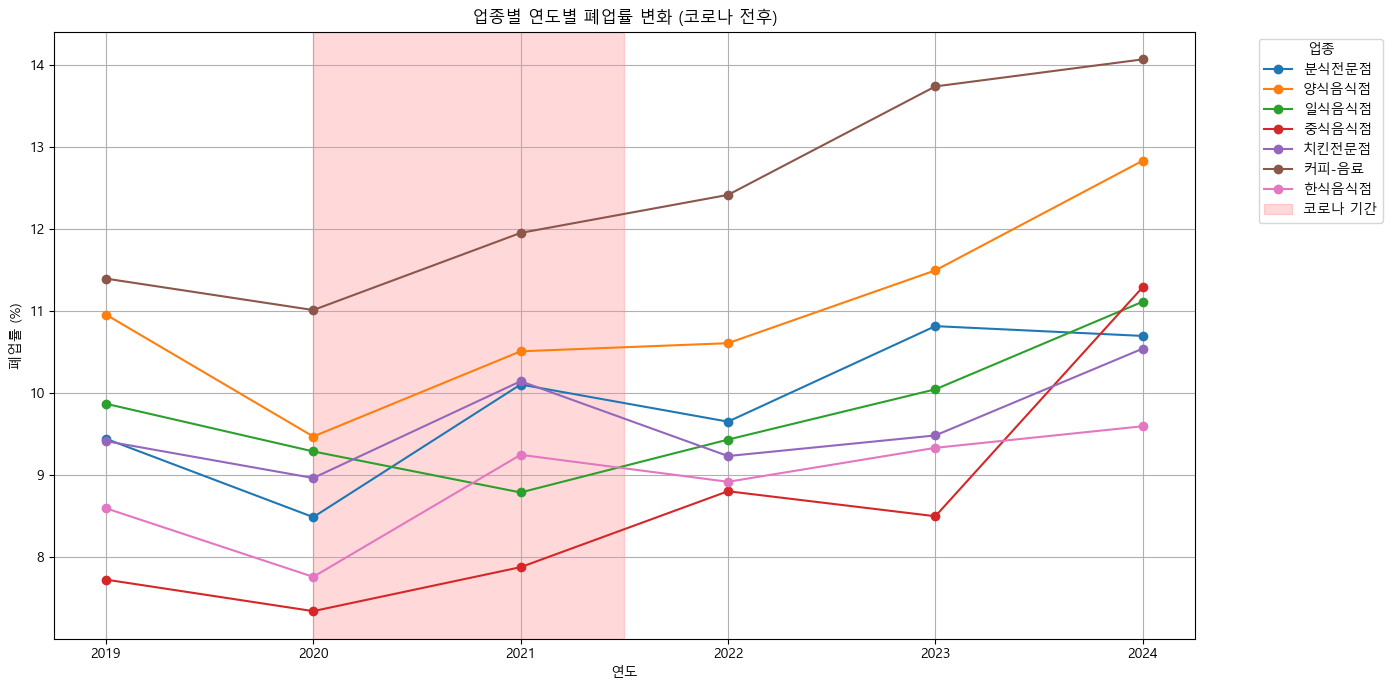

In [10]:
df_covid = df.groupby(['연도', '업종'])['폐업률'].mean().reset_index()

plt.figure(figsize=(14, 7))
for 업종 in df_covid['업종'].unique():
    temp = df_covid[df_covid['업종'] == 업종]
    plt.plot(temp['연도'], temp['폐업률'], marker='o', label=업종)

plt.axvspan(2020, 2021.5, alpha=0.15, color='red', label='코로나 기간')
plt.title('업종별 연도별 폐업률 변화 (코로나 전후)')
plt.xlabel('연도')
plt.ylabel('폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 코로나 기간(2020~2021) 평균 폐업률 9.8%  생각보다 낮은 이유는 사실상 착시 효과 이다
#### 정부의 전방위적인 지원책과 대출 유예조치로 폐업을 미루며 버틴 매장이 많다
#### 정부 지원금, 대출 만기 연장 및 이자 상환 유예 등 
#### 버티기의 결과 는 폐업 폭탄으로 이어졌다
#### 지원책이 멈추자마자 한꺼번에 무너지기 시작
#### 엔데믹 이후(2022~2024) 평균 폐업률 11.4% 정부 지원금이 전면 중단 -> 폐업률 상승으로 이어짐
#### 24년 플랫폼 개편 타격 으로 인해 배달 의존도 가 높은 업종의 폐업률 증가 (ex: 중식)
##### 배달앱 수수료 체계를 정률제(매출의 일정 %를 떼가는 방식) 위주로 강제 전환

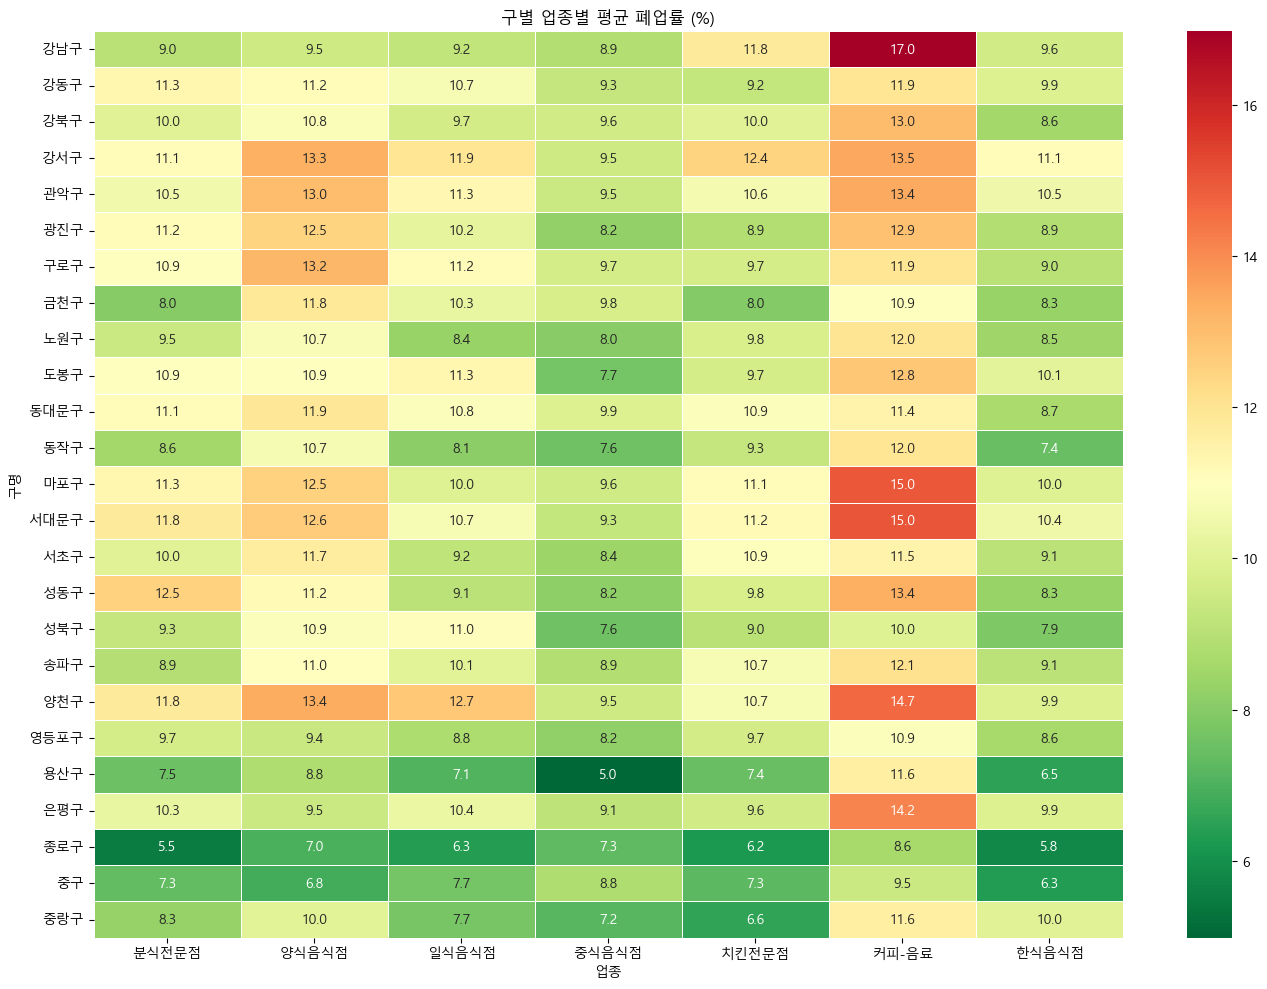

In [11]:
df_pivot = df.groupby(['구명', '업종'])['폐업률'].mean().unstack()

plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('구별 업종별 평균 폐업률 (%)')
plt.xlabel('업종')
plt.ylabel('구명')
plt.tight_layout()
plt.show()

#### 커피-음료(카폐)는 전 업종 통틀어 폐업률 압도적 1위 초과포화 상태
#### 폐업 수가 압도적인 곳: 강남구, 마포구,서대문구
#### 오피스 밀집 지역 및 대형 핫플레이스 상권, 트렌드 또는 상권이 힘을 잃으면서 밀려나는 침체형 폐업
#### 기술적 장벽 낮음, 낮은 창업 비용 등 창업자가 끊이지 않고 그만큼 폐업자도 쏟아지는 구조


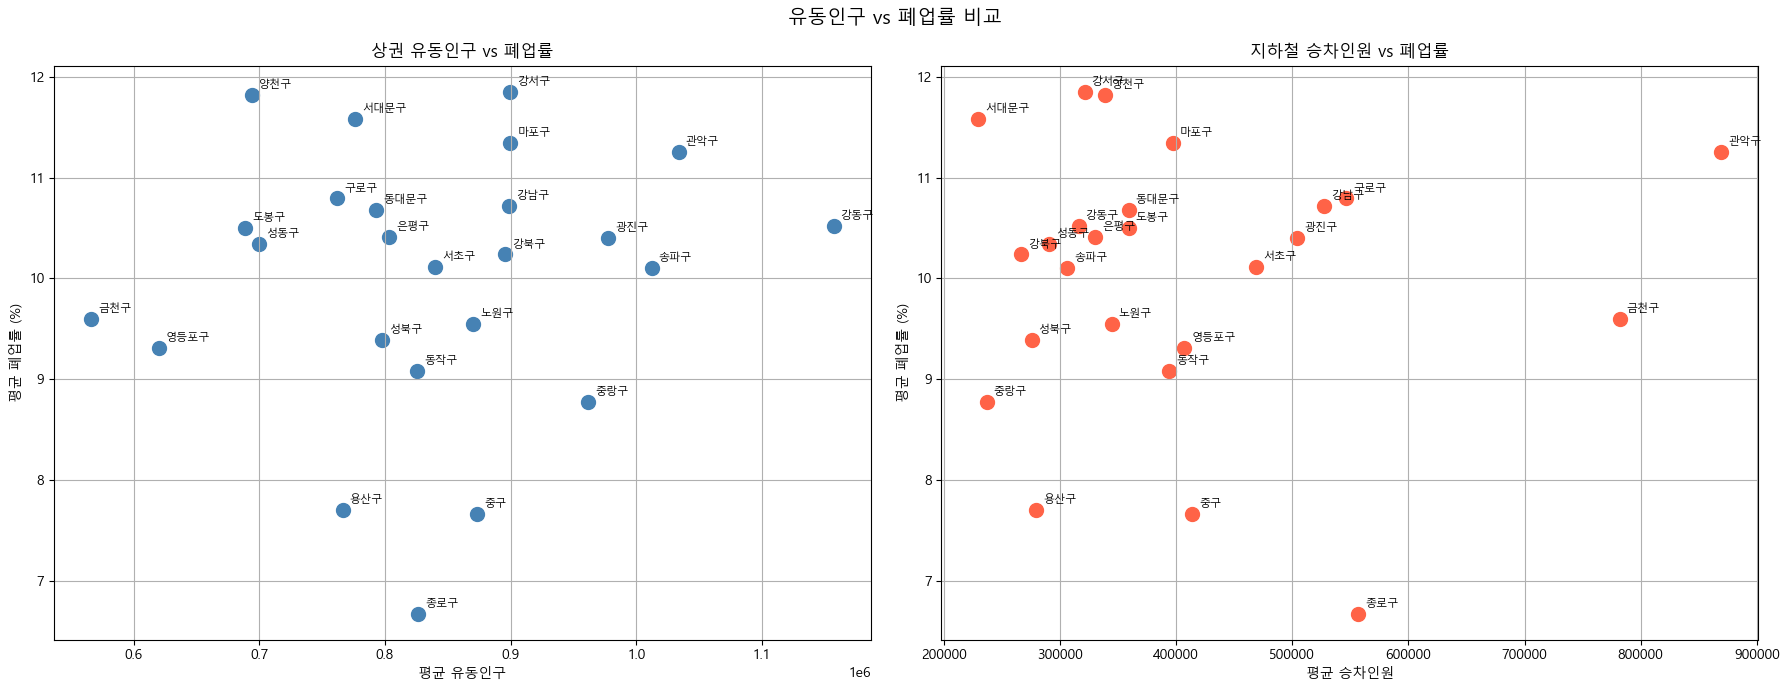

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 상권 유동인구 vs 폐업률
df_scatter = df.groupby('구명').agg(
    평균_유동인구=('총_유동인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

axes[0].scatter(df_scatter['평균_유동인구'],
                df_scatter['평균_폐업률'],
                s=100, color='steelblue')
for _, row in df_scatter.iterrows():
    axes[0].annotate(row['구명'],
                    (row['평균_유동인구'], row['평균_폐업률']),
                    textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
axes[0].set_title('상권 유동인구 vs 폐업률')
axes[0].set_xlabel('평균 유동인구')
axes[0].set_ylabel('평균 폐업률 (%)')
axes[0].grid(True)

# 오른쪽: 지하철 승차 vs 폐업률
df_subway_scatter = df.groupby('구명').agg(
    평균_승차=('평균_승차', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

axes[1].scatter(df_subway_scatter['평균_승차'],
                df_subway_scatter['평균_폐업률'],
                s=100, color='tomato')
for _, row in df_subway_scatter.iterrows():
    axes[1].annotate(row['구명'],
                    (row['평균_승차'], row['평균_폐업률']),
                    textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
axes[1].set_title('지하철 승차인원 vs 폐업률')
axes[1].set_xlabel('평균 승차인원')
axes[1].set_ylabel('평균 폐업률 (%)')
axes[1].grid(True)

plt.suptitle('유동인구 vs 폐업률 비교', fontsize=14)
plt.tight_layout()
plt.show()

#### 사람이 많이 다닌다고 해서 식당이 안 망하는 것은 아니다
#### 유동인구가 많으면 폐업률이 낮다? -> 상관관계 약함
#### 지하철 승차인원이 많으면 상권이 탄탄하다 -> 상관관계 약함
#### 임대료의 역설 - 유동인구가 많은 곳은 보통 임대료가 비싸다 
#### 유동인구 덕에 매출은 높을지 몰라도, 임대료와 인건비를 내고 나면 남는 게 없이 폐업 (ex: 강남, 마포, 관악)
#### 업종 밀집도 유동인구가 많은 곳이 많은 창업으로 이어진다
#### 종로구는 노포 중심 + 고정 오피스 수요로 유동인구와 무관하게 폐업률이 낮게 유지된다
#### 강남구 평균 매출 1위 → 폐업률 9%"
#### 관악구 유동인구 103만 → 폐업률 11.3%

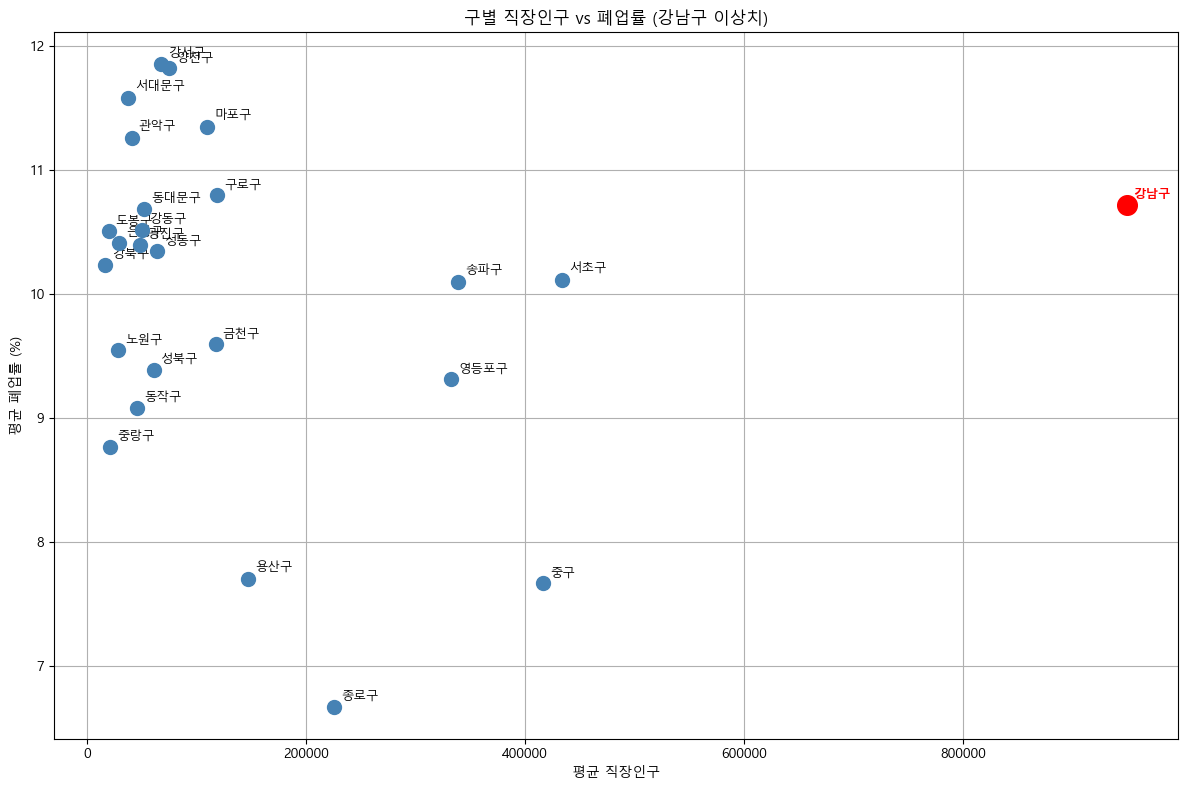

In [13]:
df_work_scatter = df.groupby('구명').agg(
    평균_직장인구=('총_직장인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))

for _, row in df_work_scatter.iterrows():
    color = 'red' if row['구명'] == '강남구' else 'steelblue'
    size = 200 if row['구명'] == '강남구' else 100
    plt.scatter(row['평균_직장인구'], row['평균_폐업률'],
                s=size, color=color, zorder=5)
    plt.annotate(row['구명'],
                (row['평균_직장인구'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9,
                color='red' if row['구명'] == '강남구' else 'black',
                fontweight='bold' if row['구명'] == '강남구' else 'normal')

plt.title('구별 직장인구 vs 폐업률 (강남구 이상치)')
plt.xlabel('평균 직장인구')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
구_list = ['강서구', '양천구', '서대문구', '관악구']

df_check = df[df['구명'].isin(구_list)].groupby(['구명', '업종'])['폐업률'].mean().unstack()
print(df_check.round(2))

업종    분식전문점  양식음식점  일식음식점  중식음식점  치킨전문점  커피-음료  한식음식점
구명                                                   
강서구   11.15  13.31  11.94   9.51  12.45  13.47  11.14
관악구   10.52  13.03  11.28   9.46  10.63  13.43  10.48
서대문구  11.79  12.64  10.74   9.28  11.19  15.03  10.42
양천구   11.80  13.39  12.74   9.48  10.74  14.66   9.93


#### 직장인은 없는데 경쟁은 치열 
#### 주거 밀집 지역 (강서, 양천, 서대문, 관악) 은 진입장벽이 낮은 배달전문점, 커피, 치킨전문점 창업이 높은편
#### 커피-음료 평균 폐업률 14.15% ,치킨전문점 평균 폐업률 11.25%
#### 직장인 상권처럼 점심/저녁 회식 같은 '확실한 객단가'가 보장되지 않고, 동네 주민만을 대상으로 치열한 가격 경쟁
#### 직장인이 적은 곳에서 폐업률이 치솟는 현상



#### 강남구의 역설 : 직장인이 압도적인데도 폐업률 높음
#### 강남구 → 통계적 이상치 
#### 직장인구 1위 → 일반적으로 폐업률이 낮아야 정상
#### 근데 폐업률 10.7% → 서울 평균보다 높음
#### 직장인 수요만으로는 설명 불가능한 유일한 구
#### 원인: 과잉 경쟁 + 높은 임대료/권리금의 복합 작용

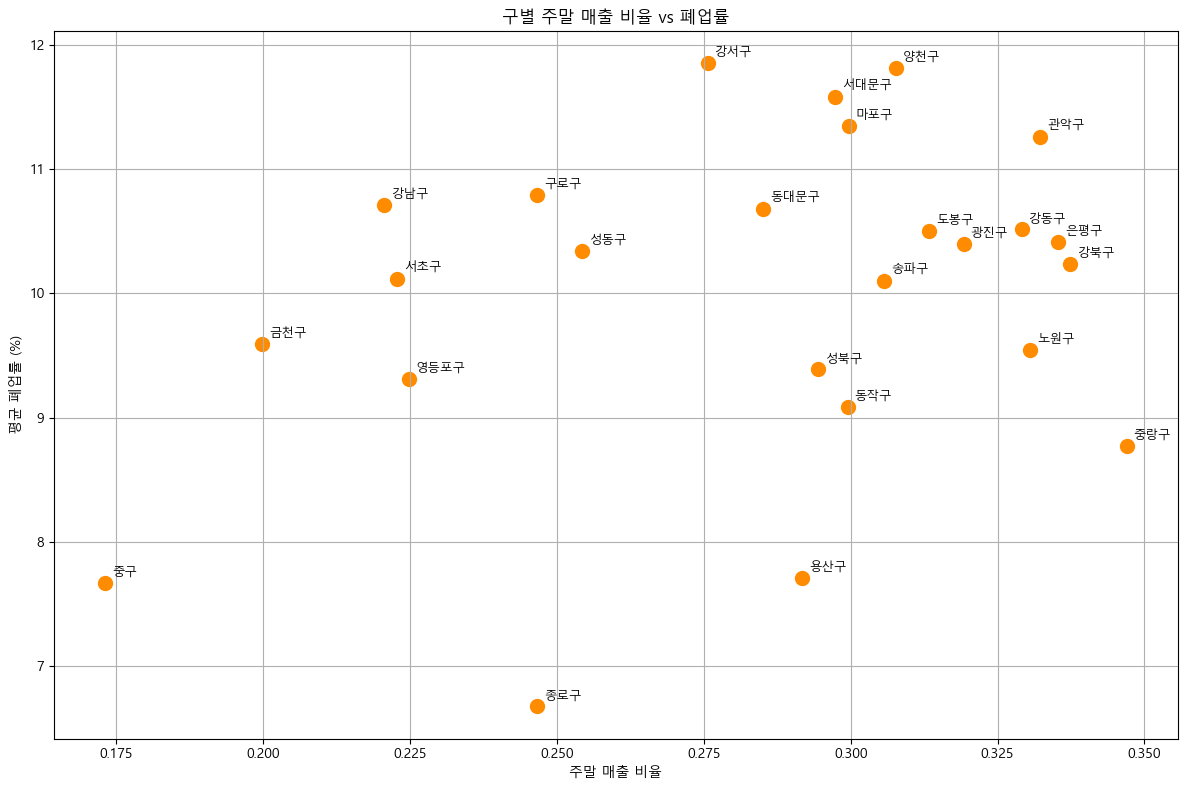

In [15]:
df_weekend = df.groupby('구명').agg(
    평균_주말비율=('주말_매출_비율', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_weekend['평균_주말비율'],
            df_weekend['평균_폐업률'],
            s=100, color='darkorange')

for _, row in df_weekend.iterrows():
    plt.annotate(row['구명'],
                (row['평균_주말비율'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 주말 매출 비율 vs 폐업률')
plt.xlabel('주말 매출 비율')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 주말 매출 비중이 높다 = 주간 직장인 수요가 없다 = 평일 고정 수요 없음 = 매출 변동성 높음 = 폐업 위험
#### 구별 직장인구 vs 폐업률 과 구별 주말 매출 비율 vs 폐업률 비교 하면 더욱 뚜렷해지는 결과
#### 주거 밀집지 0.325 이상 → 평균 폐업률 10 ~ 12% (강동구, 은평구, 강북구, 중랑구, 노원구) 일주일 중 단 이틀(주말) 매출에 목을 매야 하는 구조
#### 직장인 상권 중구와 종로구 주말 매출 비율이 0.175 ~ 0.25 수준 으로 매우 낮음 → 평균 폐업률 7~9%"
#### 강남구의 '특이점' 재확인  주말 매출 비중이 약 0.22로 매우 낮은편 논리적으로는 종로·중구처럼 폐업률이 낮아야 하는데, 강남구는 폐업률이 11% 육박

#### 중랑구: 직장인수 최하위권 인데 폐업률도 최하위권(8%대) 생계형 노포와 저렴한 임대료 같은 케이스
#### 용산구: 직장인구 대비 폐업률이 매우 낮게(7%대)  독점적 핫플레이스의 힘 ( 용리단길, 한남동, 이태원 등) 은 대체 불가능한 상권
#### 고정비 대비 수요가 안정적

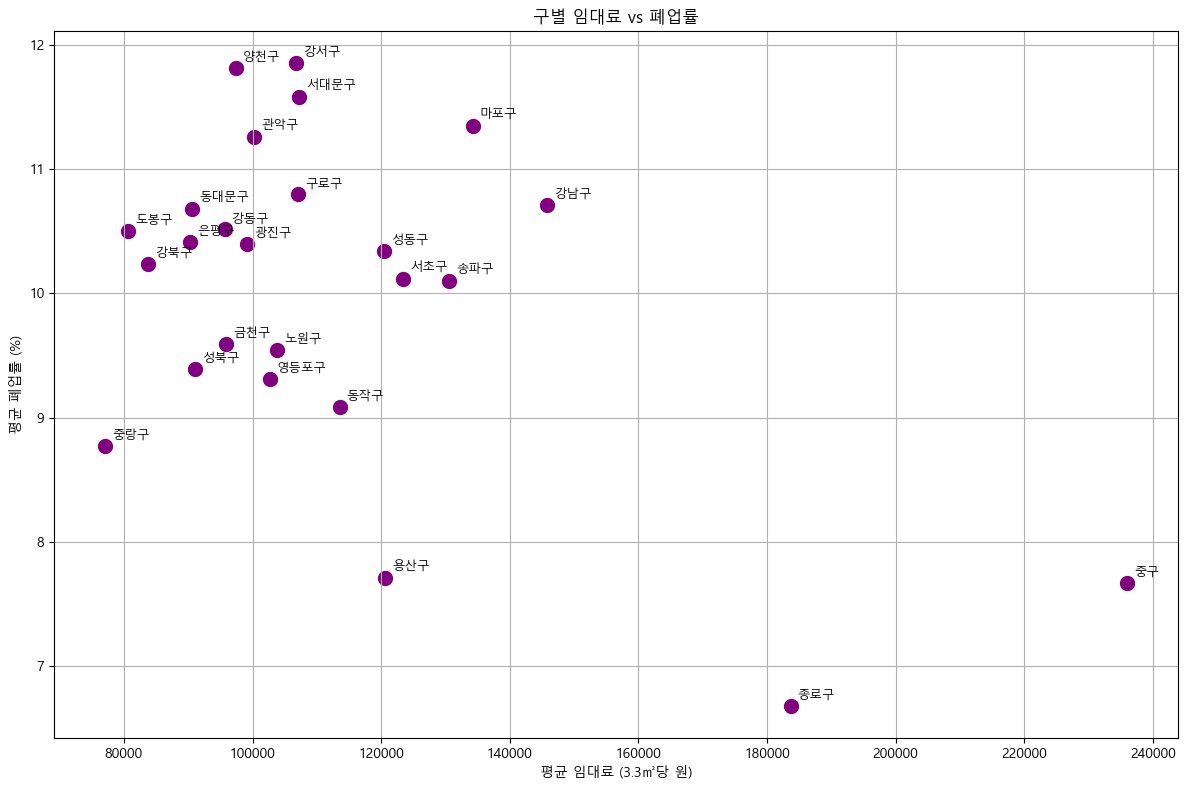

In [16]:
df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv',
                 encoding='utf-8-sig')

df_rent_scatter = df.groupby('구명').agg(
    평균_임대료=('임대료', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_rent_scatter['평균_임대료'],
            df_rent_scatter['평균_폐업률'],
            s=100, color='purple')

for _, row in df_rent_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_임대료'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 임대료 vs 폐업률')
plt.xlabel('평균 임대료 (3.3㎡당 원)')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

####  임대료가 비싼데 폐업률이 낮은 곳도 있고 높은 곳도 있어. 임대료 단독으로는 설명 불가

In [17]:
import pandas as pd
df_survival = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/업종별_평균생존년수.csv',
                          encoding='utf-8-sig')

In [18]:
import pandas as pd

df1 = pd.read_csv('C:/Users/human/미정프로젝트/서울시 일반음식점 인허가 정보.csv',
                  encoding='cp949', encoding_errors='replace', low_memory=False)
df2 = pd.read_csv('C:/Users/human/미정프로젝트/서울시 휴게음식점 인허가 정보.csv',
                  encoding='cp949', encoding_errors='replace', low_memory=False)

df1['업종구분'] = '일반음식점'
df2['업종구분'] = '휴게음식점'
df = pd.concat([df1, df2], ignore_index=True)

cols = ['사업장명', '업태구분명', '업종구분', '영업상태명', '인허가일자', '폐업일자', '도로명주소']
df = df[cols].copy()

df['인허가일자'] = pd.to_datetime(df['인허가일자'], errors='coerce')
df['폐업일자'] = pd.to_datetime(df['폐업일자'], errors='coerce')
df['구명'] = df['도로명주소'].str.extract(r'서울특별시\s+(\S+구)')
df_seoul = df[df['구명'].notna()].copy()

업종_매핑 = {
    '한식': '한식음식점', '커피숍': '커피-음료',
    '경양식': '양식음식점', '일식': '일식음식점',
    '중국식': '중식음식점', '호프/통닭': '치킨전문점',
    '분식': '분식전문점',
}

df_food = df_seoul[df_seoul['업태구분명'].isin(업종_매핑.keys())].copy()
df_food['업종'] = df_food['업태구분명'].map(업종_매핑)

# 폐업한 가게만 추출 (폐업일자 있는 것)
df_closed_all = df_food[df_food['폐업일자'].notna()].copy()
df_closed_all['생존_년수'] = ((df_closed_all['폐업일자'] - df_closed_all['인허가일자']).dt.days / 365).round(1)

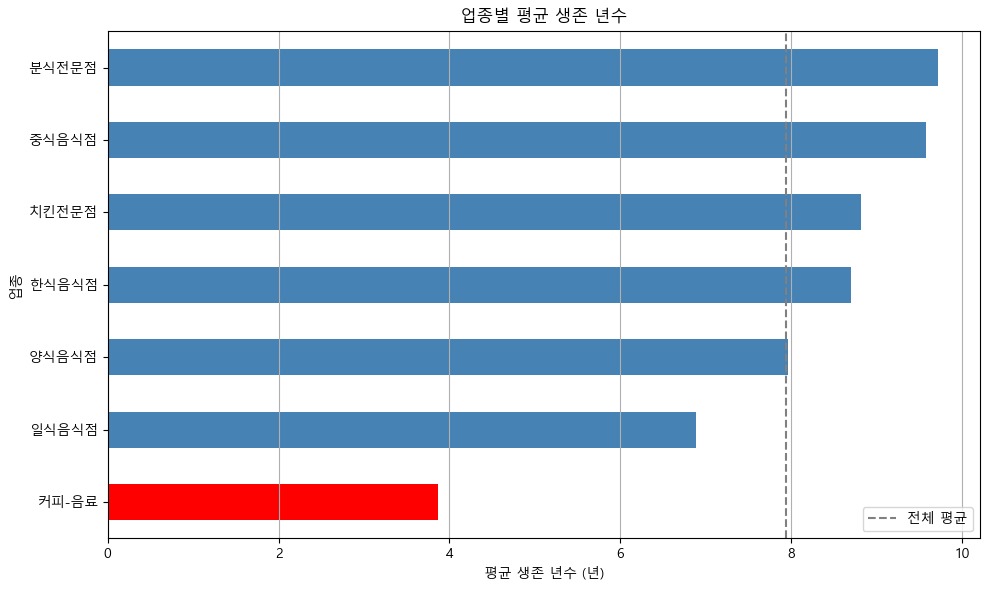

업종
커피-음료    3.9
일식음식점    6.9
양식음식점    8.0
한식음식점    8.7
치킨전문점    8.8
중식음식점    9.6
분식전문점    9.7
Name: 생존_년수, dtype: float64


In [19]:
df_survival_year = df_closed_all.groupby('업종')['생존_년수'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if 업종 == '커피-음료' else 'steelblue' for 업종 in df_survival_year.index]
df_survival_year.plot(kind='barh', color=colors)

plt.title('업종별 평균 생존 년수')
plt.xlabel('평균 생존 년수 (년)')
plt.ylabel('업종')
plt.axvline(x=df_survival_year.mean(), color='gray', linestyle='--', label='전체 평균')
plt.legend(handles=[plt.Line2D([0], [0], color='gray', linestyle='--', label='전체 평균')])
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print(df_survival_year.round(1))

#### 업종별 생존 년수 를 볼때 확실히  커피-음료(카폐)의 수명이 짧음
#### 경쟁강도가 더욱 심화 될수 밖에 없는 부분
#### 지역의 선택도 중요 하지만 업종의 선택 또한 폐업률의 큰 영향을 줌

In [20]:
pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
df_ml = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv', encoding='utf-8-sig')

df_comp_scatter = df_ml.groupby('구명').agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

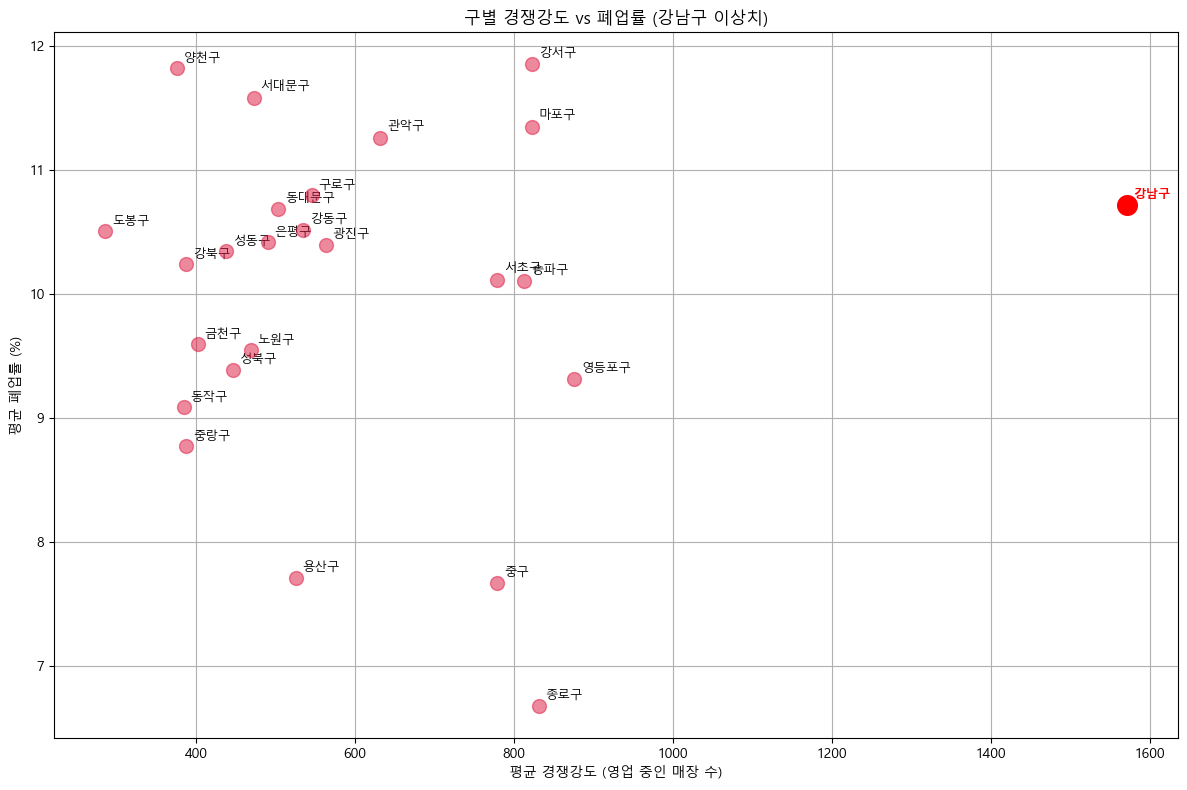

In [22]:
df_comp_scatter = df_ml.groupby('구명').agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))

for _, row in df_comp_scatter.iterrows():
    color = 'red' if row['구명'] == '강남구' else 'crimson'
    size = 200 if row['구명'] == '강남구' else 100
    alpha = 1.0 if row['구명'] == '강남구' else 0.5
    plt.scatter(row['평균_경쟁강도'],
                row['평균_폐업률'],
                s=size, color=color, alpha=alpha, zorder=5)
    plt.annotate(row['구명'],
                (row['평균_경쟁강도'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9,
                color='red' if row['구명'] == '강남구' else 'black',
                fontweight='bold' if row['구명'] == '강남구' else 'normal')

plt.title('구별 경쟁강도 vs 폐업률 (강남구 이상치)')
plt.xlabel('평균 경쟁강도 (영업 중인 매장 수)')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

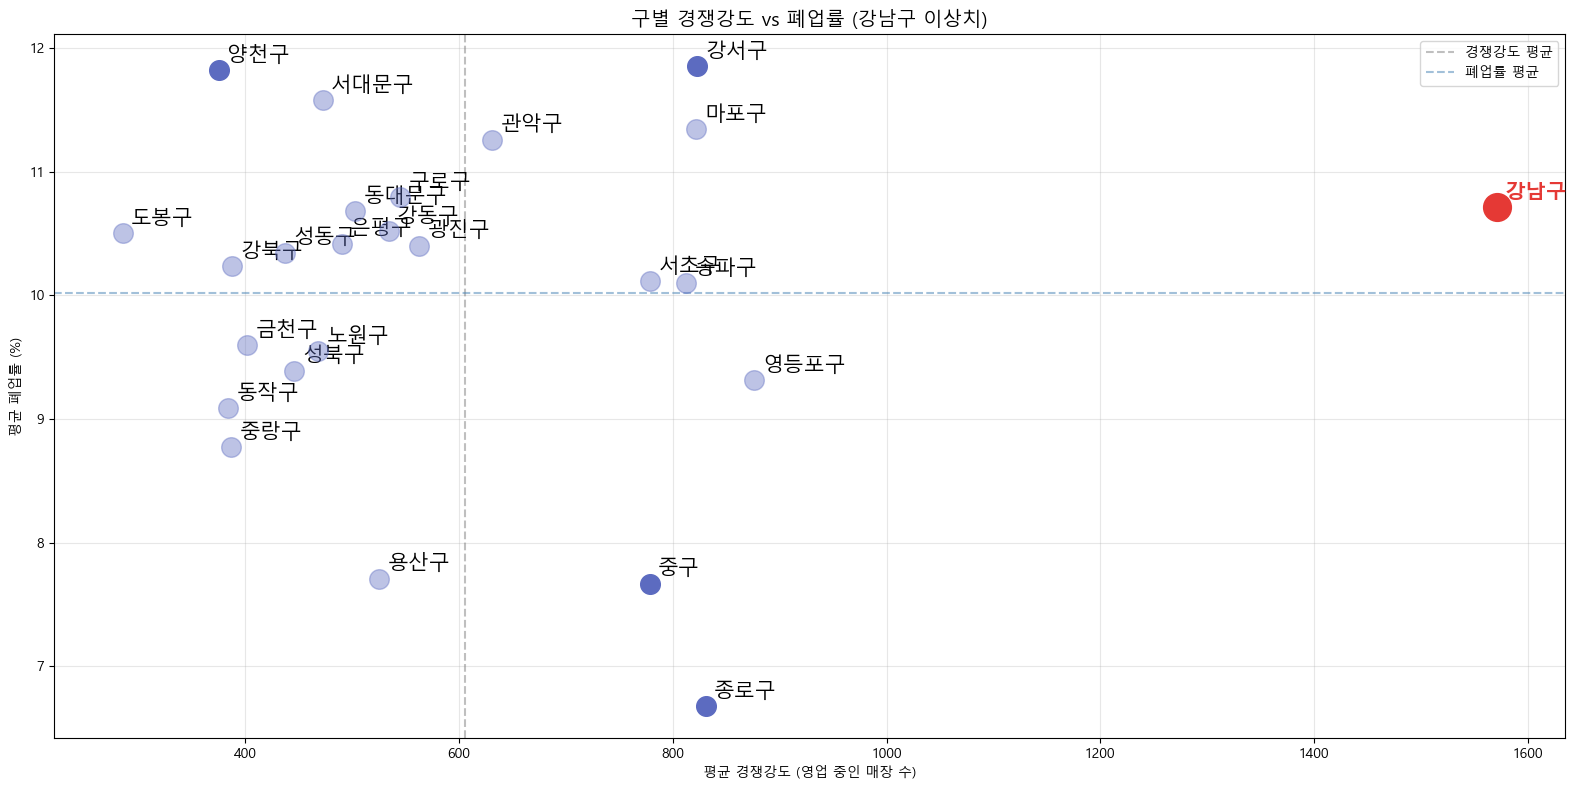

In [30]:
df_comp_scatter = df_ml.groupby('구명').agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

# 강조할 구만 이름 표시
강조_구 = ['강남구', '종로구', '중구', '강서구', '양천구']

fig, ax = plt.subplots(figsize=(16, 8))

for _, row in df_comp_scatter.iterrows():
    is_gangnam = row['구명'] == '강남구'
    is_강조 = row['구명'] in 강조_구
    
    color = '#E53935' if is_gangnam else '#5C6BC0'
    size = 400 if is_gangnam else 200
    alpha = 1.0 if is_강조 else 0.4
    
    ax.scatter(row['평균_경쟁강도'], row['평균_폐업률'],
               s=size, color=color, alpha=alpha, zorder=5)
    
    
    ax.annotate(row['구명'],
                (row['평균_경쟁강도'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(6, 6), fontsize=15,
                color='#E53935' if is_gangnam else 'black',
                fontweight='bold' if is_gangnam else 'normal')

ax.axvline(x=df_comp_scatter['평균_경쟁강도'].mean(), color='gray', linestyle='--', alpha=0.5, label='경쟁강도 평균')
ax.axhline(y=df_comp_scatter['평균_폐업률'].mean(), color='steelblue', linestyle='--', alpha=0.5, label='폐업률 평균')

ax.set_title('구별 경쟁강도 vs 폐업률 (강남구 이상치)', fontsize=14)
ax.set_xlabel('평균 경쟁강도 (영업 중인 매장 수)')
ax.set_ylabel('평균 폐업률 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import folium
import requests

df_ml = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv', encoding='utf-8-sig')

df_gu = df_ml.groupby('구명').agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

# 서울시 구 경계 GeoJSON
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_data = requests.get(geo_url).json()

# 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 폐업률 코로플레스 지도
folium.Choropleth(
    geo_data=geo_data,
    data=df_gu,
    columns=['구명', '평균_폐업률'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='평균 폐업률 (%)',
    highlight=True
).add_to(m)

# 구별 이름 + 수치 툴팁
for _, row in df_gu.iterrows():
    folium.Marker(
        location=[0, 0],  # 임시
    )

m.save('C:/Users/human/미정프로젝트/서울_폐업률_지도.html')
print("저장 완료")

저장 완료


In [25]:
df_comp_scatter = df.groupby(['구명', '업종']).agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

업종목록 = df_comp_scatter['업종'].unique()
colors = plt.cm.Set1.colors

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    
    for _, row in temp.iterrows():
        is_gangnam = row['구명'] == '강남구'
        axes[i].scatter(row['평균_경쟁강도'],
                        row['평균_폐업률'],
                        s=200 if is_gangnam else 100,
                        color='red' if is_gangnam else colors[i],
                        zorder=5 if is_gangnam else 3)
        axes[i].annotate(row['구명'],
                        (row['평균_경쟁강도'], row['평균_폐업률']),
                        fontsize=7 if not is_gangnam else 9,
                        fontweight='bold' if is_gangnam else 'normal',
                        color='red' if is_gangnam else 'black',
                        xytext=(3, 3),
                        textcoords='offset points')

    axes[i].set_title(f'{업종}')
    axes[i].set_xlabel('평균 경쟁강도 (매장수)')
    axes[i].set_ylabel('폐업률 (%)')
    axes[i].grid(True)

axes[-1].set_visible(False)
plt.suptitle('업종별 경쟁강도 vs 폐업률 (강남구 이상치)', fontsize=15)
plt.tight_layout()
plt.show()

KeyError: '업종'

In [ ]:
plt.figure(figsize=(12, 8))

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    plt.scatter(temp['평균_경쟁강도'],
                temp['평균_폐업률'],
                s=80, color=colors[i], label=업종, alpha=0.7)

# 추세선 추가
import numpy as np
x = df_comp_scatter['평균_경쟁강도']
y = df_comp_scatter['평균_폐업률']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(sorted(x), p(sorted(x)), color='black', linestyle='--', label='추세선')

plt.title('경쟁강도 vs 폐업률 (업종별)')
plt.xlabel('평균 경쟁강도 (매장수)')
plt.ylabel('평균 폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 강남구는 경쟁강도 1,600개로 서울 평균의 3배 → 단일 변수로 설명되는 유일한 이상치
#### 임대료와 경쟁강도를 추가 변수로 투입했으나 EDA 단계에서는 폐업률과의 직접적 상관관계가 뚜렷하지 않았다. 
#### 이는 단일 변수보다 복합적 요인이 폐업에 영향을 준다는 것을 시사한다

### 종합
#### 유동인구의 함정  사람이 많다고 장사가 잘 되는 게 아니다 → 유동인구보다 직장인 고정수요가 핵심
#### 코로나 착시와 폐업 폭탄 2020 ~ 2021 → 지원금으로 폐업 억제  → 2022~2024 → 지원 종료 + 고물가 → 폐업 급등
#### 업종 선택이 생존을 결정한다 어디서 창업하느냐보다 뭘 창업하느냐가 중요
#### 커피 → 전 지역 폐업률 1위 (평균 생존 2~4년)
#### 중식/한식 → 전 지역 안정적 (평균 생존 8~10년)
#### 강남구 커피 → 2.1년 (서울 평균 3.9년의 절반)

##### 유동인구가 많은 곳이 아니라, 직장인 고정수요가 있고 경쟁이 덜한 곳에서 안정적 업종으로 창업하는 것이 생존 확률을 높인다